## Handwritten Digits Recognition System using CNN

## Step 1 Install Required Libraries

In [ ]:
pip install tensorflow streamlit matplotlib seaborn pandas numpy scikit-learn pillow opencv-python streamlit-drawable-canvas

## Step 2 Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

## Step 3 Load Dataset

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (60000, 28, 28)
Testing Data Shape: (10000, 28, 28)


## Step 4 Exploratory Data Analysis (EDA)
### 4.1 Display Sample Images

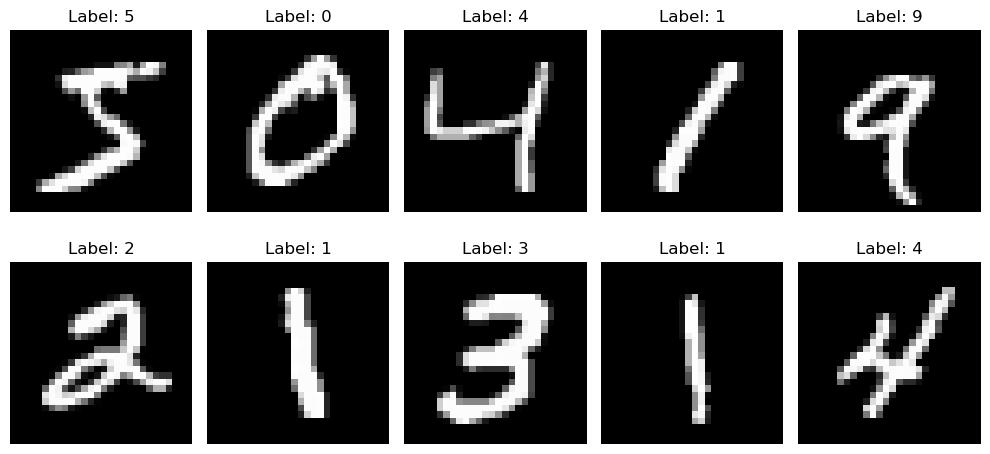

In [3]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.tight_layout()
plt.savefig("sample_digits.png", bbox_inches='tight')
plt.show()

### 4.2 Class Distribution Graph

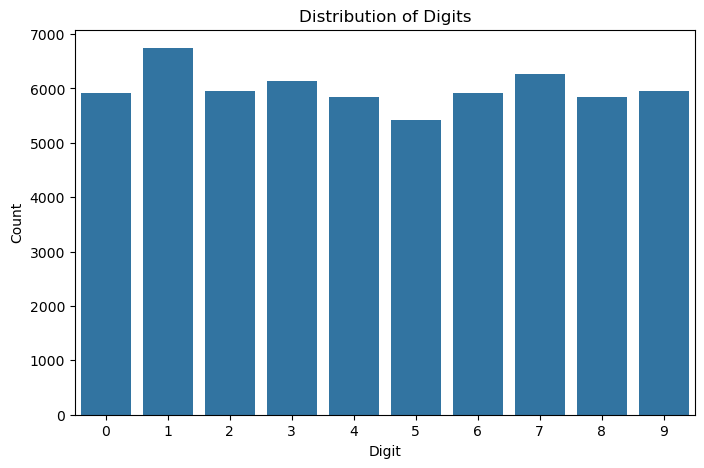

In [4]:
plt.figure(figsize=(8,5))
sns.countplot(x=y_train)
plt.title("Distribution of Digits")
plt.xlabel("Digit")
plt.ylabel("Count")
plt.savefig("class_distribution.png", bbox_inches='tight')
plt.show()

### 4.3. Pixel intensity distribution

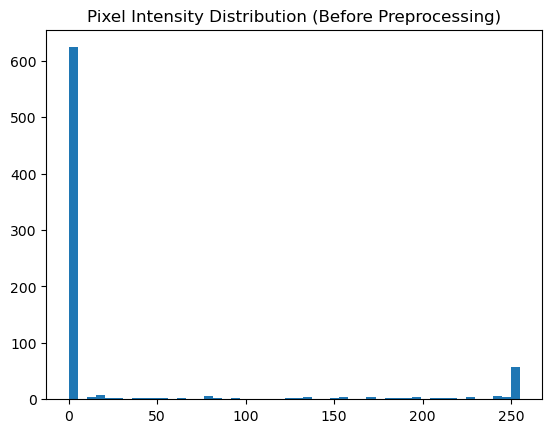

In [5]:
plt.hist(X_train[0].ravel(), bins=50)
plt.title("Pixel Intensity Distribution (Before Preprocessing)")
plt.savefig("pixel_intensity_distribution.png", bbox_inches='tight')
plt.show()

### 4.5 Before Preprocessing Image Visualization

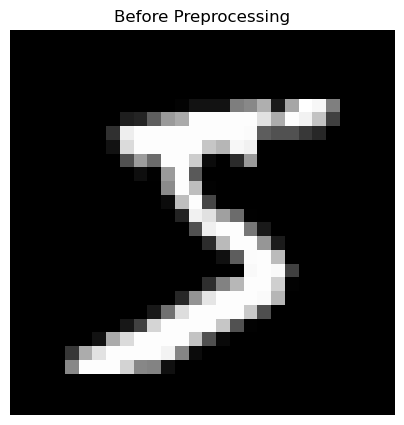

In [6]:
plt.figure(figsize=(5,5))
plt.imshow(X_train[0], cmap='gray')
plt.title("Before Preprocessing")
plt.axis('off')
plt.savefig("before_preprocessing.png", bbox_inches='tight')
plt.show()

## Step 5 Data Preprocessing
### 5.1 Normalize Pixel Values

In [7]:
X_train = X_train / 255.0
X_test = X_test / 255.0

### 5.2 Reshape Datase

In [8]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

### 5.3 One-Hot Encode Labels

In [9]:
# 3 -> [0,0,0,1,0,0,0,0,0,0]
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

## Step 6 Train Validation Split

In [10]:
X_train, X_val, y_train_cat, y_val_cat = train_test_split(
    X_train,
    y_train_cat,
    test_size=0.1,
    random_state=42
)

## Step 7 After Preprocessing Visualization

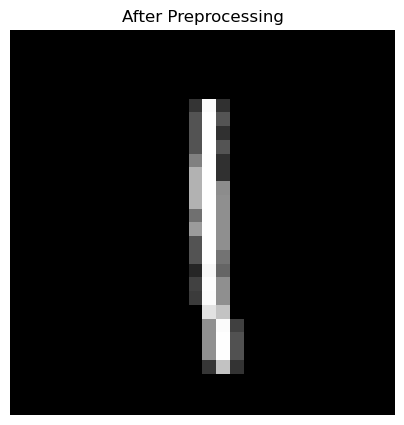

In [11]:
plt.figure(figsize=(5,5))
plt.imshow(X_train[0].reshape(28,28), cmap='gray')
plt.title("After Preprocessing")
plt.axis('off')
plt.savefig("after_preprocessing.png", bbox_inches='tight')
plt.show()

## Step 8 Build CNN Model
### CNN Architecture

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

model = Sequential()

# Input layer
model.add(Input(shape=(28, 28, 1)))

# First Convolution Layer
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))

# Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Second Convolution Layer
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))

# Second Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
model.add(Flatten())

# Dense Layer
model.add(Dense(128, activation='relu'))

# Dropout Layer
model.add(Dropout(0.3))

# Output Layer
model.add(Dense(10, activation='softmax'))

## Step 9 Compile Model

In [13]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## Step 10 Train Model

In [14]:
history = model.fit(
    X_train,
    y_train_cat,
    epochs=15,
    batch_size=32,
    validation_data=(X_val, y_val_cat)
)

Epoch 1/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 35s 17ms/step - accuracy: 0.9452 - loss: 0.1788 - val_accuracy: 0.9828 - val_loss: 0.0542
Epoch 2/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 41s 17ms/step - accuracy: 0.9814 - loss: 0.0611 - val_accuracy: 0.9888 - val_loss: 0.0374
Epoch 3/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 42s 18ms/step - accuracy: 0.9858 - loss: 0.0448 - val_accuracy: 0.9892 - val_loss: 0.0374
Epoch 4/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 41s 18ms/step - accuracy: 0.9897 - loss: 0.0343 - val_accuracy: 0.9907 - val_loss: 0.0369
Epoch 5/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 25s 15ms/step - accuracy: 0.9910 - loss: 0.0285 - val_accuracy: 0.9902 - val_loss: 0.0345
Epoch 6/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 28s 17ms/step - accuracy: 0.9930 - loss: 0.0223 - val_accuracy: 0.9913 - val_loss: 0.0325
Epoch 7/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 25s 15ms/step - accuracy: 0.9934 - loss: 0.0200 - val_accuracy: 0.9902 - val_loss: 0.0391
Epoch 8/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 43s 16ms/step - accuracy: 0.9942 -

## Step 11 Model Summary

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 675,104 (2.58 MB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 450,070 (1.72 MB)

## Step 12 Training Accuracy Graph

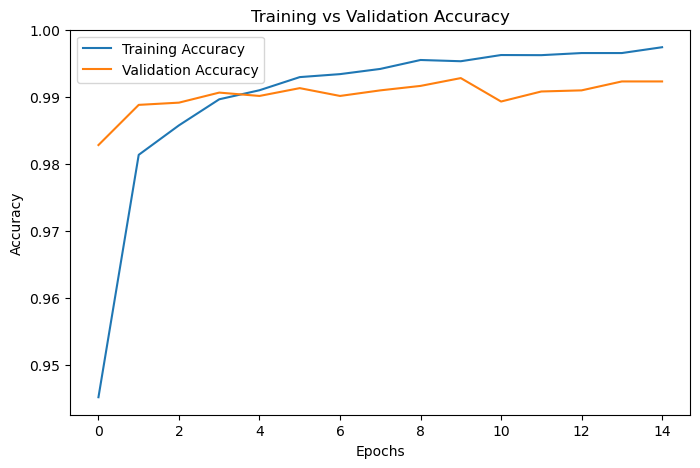

In [16]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.legend()
plt.savefig("accuracy_curve.png", bbox_inches='tight')
plt.show()

## Step 13 Loss Function Graph

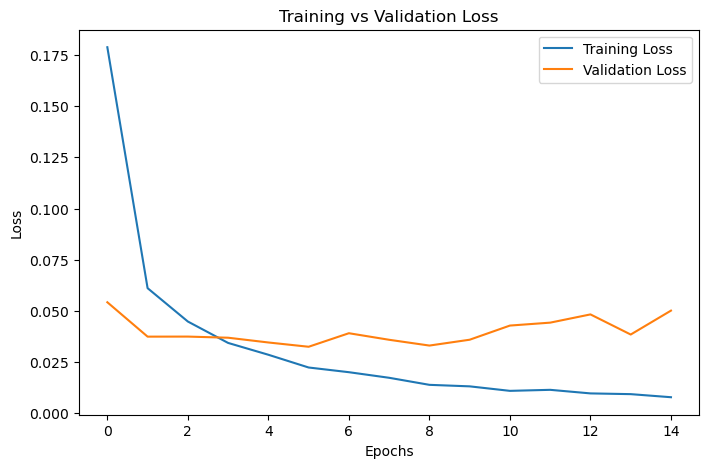

In [17]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig("loss_curve.png", bbox_inches='tight')
plt.show()

## Step 14 Evaluate Model

In [18]:
loss, accuracy = model.evaluate(X_test, y_test_cat)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9930 - loss: 0.0373
Test Loss: 0.0372881218791008
Test Accuracy: 0.9929999709129333


## Step 15 Predictions

In [19]:
predictions = model.predict(X_test)
predicted_labels = np.argmax(predictions, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


## Step 16 Confusion Matrix

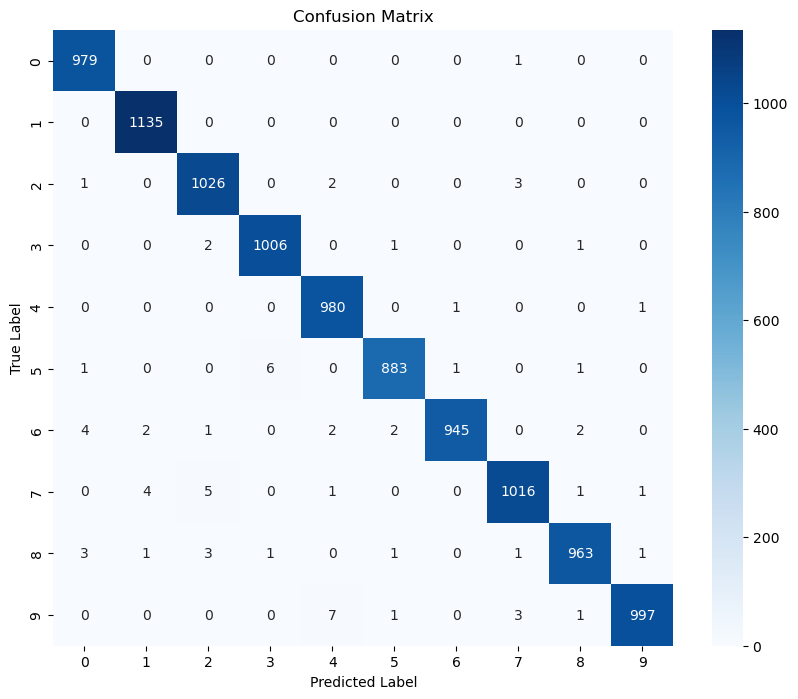

In [20]:
cm = confusion_matrix(y_test, predicted_labels)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig("confusion matrix.png", bbox_inches='tight')
plt.show()

## Step 17 Classification Report

In [21]:
print(classification_report(y_test, predicted_labels))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      1.00      0.99      1010
           4       0.99      1.00      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       1.00      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



## Step 18 Display Predictions

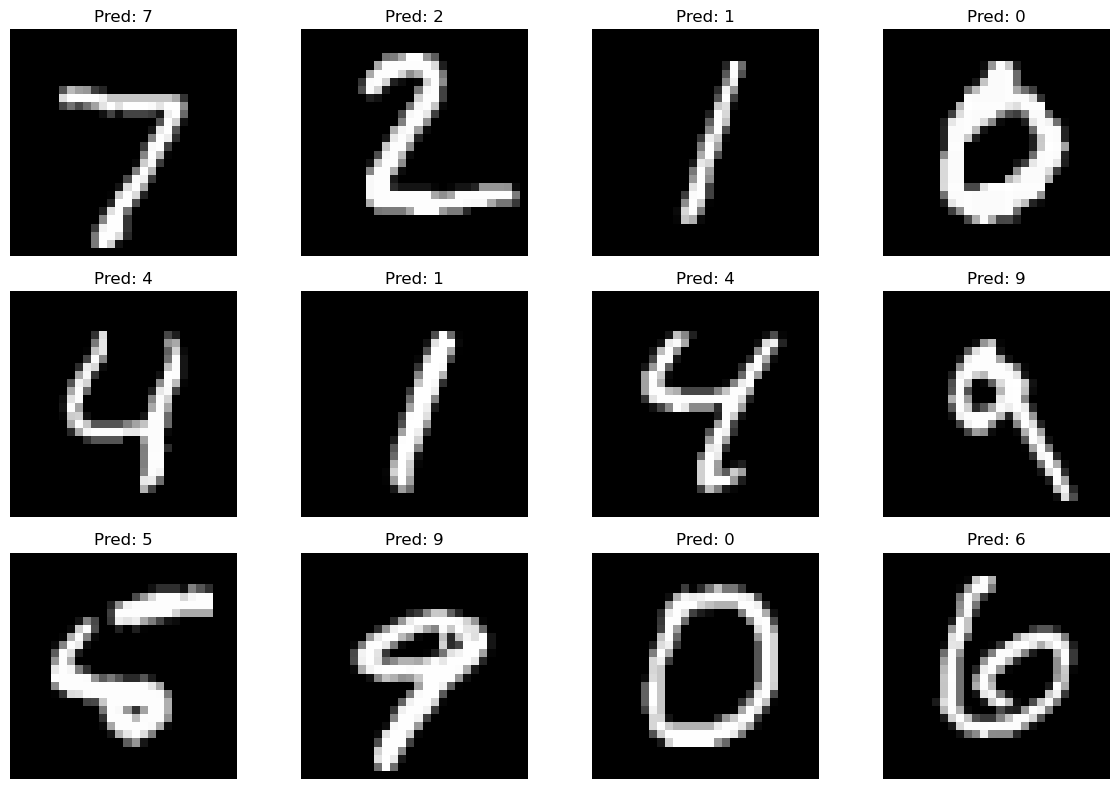

In [23]:
plt.figure(figsize=(12,8))

for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title(f"Pred: {predicted_labels[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## Step 19 Save Model

In [27]:
model.save('digit_model.keras')

### Step 18.1 Prediction Visualization Graph

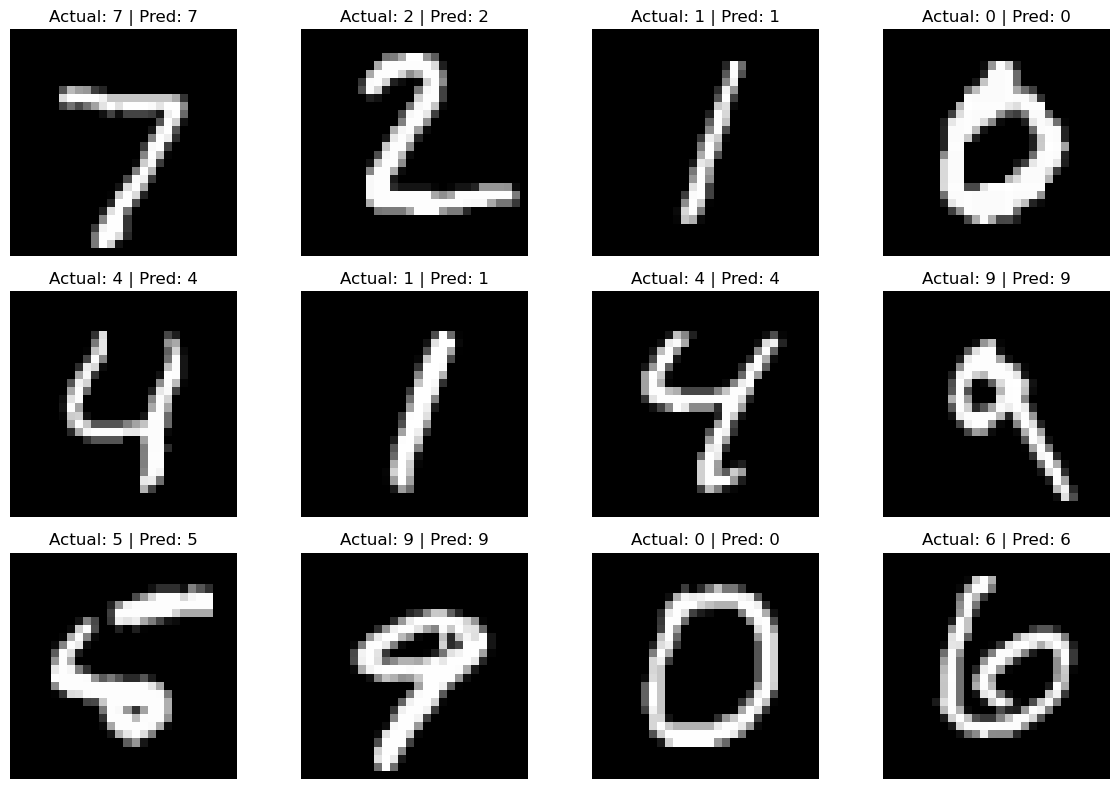

In [24]:
plt.figure(figsize=(12,8))

for i in range(12):
    plt.subplot(3,4,i+1)

    plt.imshow(X_test[i].reshape(28,28), cmap='gray')

    actual_label = y_test[i]
    predicted_label = predicted_labels[i]

    plt.title(f"Actual: {actual_label} | Pred: {predicted_label}")
    plt.axis('off')

plt.tight_layout()
plt.savefig("predictions.png", bbox_inches='tight')
plt.show()

### Step 18.2 Sample Misclassified Images Graph

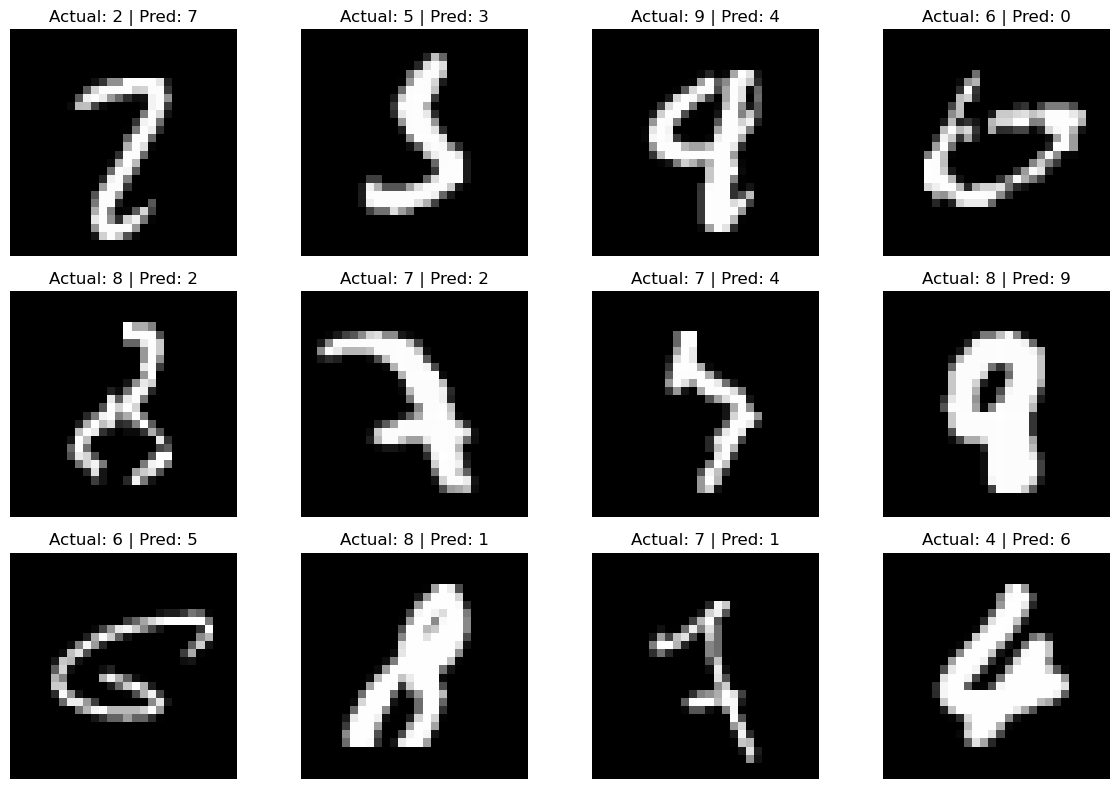

In [25]:
misclassified_indexes = np.where(predicted_labels != y_test)[0]

plt.figure(figsize=(12,8))

for i, index in enumerate(misclassified_indexes[:12]):
    plt.subplot(3,4,i+1)

    plt.imshow(X_test[index].reshape(28,28), cmap='gray')

    plt.title(
        f"Actual: {y_test[index]} | Pred: {predicted_labels[index]}"
    )

    plt.axis('off')

plt.tight_layout()
plt.savefig("misclassified_images.png", bbox_inches='tight')
plt.show()

## Final Accuracy Comparison Bar Chart
### Train vs Validation vs Test

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9930 - loss: 0.0373


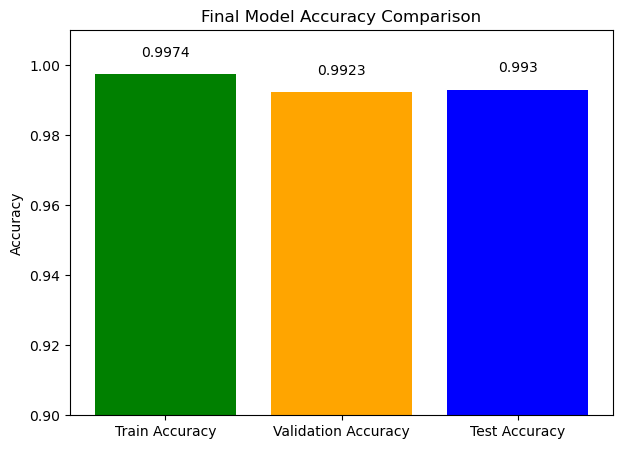

In [26]:
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

test_loss, test_acc = model.evaluate(X_test, y_test_cat)

# Labels and values
labels = ['Train Accuracy', 'Validation Accuracy', 'Test Accuracy']
values = [train_acc, val_acc, test_acc]

# Colors for each bar
colors = ['green', 'orange', 'blue']

plt.figure(figsize=(7,5))
bars = plt.bar(labels, values, color=colors)

# Add value labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, round(yval, 4), ha='center')

plt.title("Final Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0.9, 1.01)
plt.savefig("accuracy_comparison.png", bbox_inches='tight')
plt.show()